In [80]:
import pandas as pd
data = pd.read_csv("data_bersih2.csv")
data

,id_tender,judul_tender,jenis_prosedur,jenis_pengadaan,jumlah_lot,jumlah_penawaran_terekam,tanggal_kontrak,tanggal_keputusan_pemenang,harga_estimasi,harga_penawaran,...,indikator_penawar_tunggal,indikator_prosedur_berisiko,durasi_penawaran,indikator_submisi_berisiko,durasi_keputusan,indikator_keputusan_berisiko,konsentrasi_instansi,skor_risiko_korupsi,ada_harga_penawaran,label
0,64a79b42-048e-4930-b016-85fdb8ca1268,BELANJA MODAL BANGUNAN PENGAMANAN SUNGAI,OPEN,WORKS,1.0,15.0,8/4/2021,7/14/2021,5.667410e+08,447099201.0,...,0.0,0.0,6.0,1.0,15.0,0.0,0.006925,0.201385,1.0,0
1,64a79b42-048e-4930-b016-85fdb8ca1268,BELANJA MODAL BANGUNAN PENGAMANAN SUNGAI,OPEN,WORKS,1.0,15.0,8/4/2021,7/14/2021,5.667410e+08,414476414.0,...,0.0,0.0,6.0,1.0,15.0,0.0,0.006420,0.201284,1.0,0
2,64a79b42-048e-4930-b016-85fdb8ca1268,BELANJA MODAL BANGUNAN PENGAMANAN SUNGAI,OPEN,WORKS,1.0,15.0,8/4/2021,7/14/2021,5.667410e+08,468840095.0,...,0.0,0.0,6.0,1.0,15.0,0.0,0.007262,0.201452,1.0,0
3,64a79b42-048e-4930-b016-85fdb8ca1268,BELANJA MODAL BANGUNAN PENGAMANAN SUNGAI,OPEN,WORKS,1.0,15.0,8/4/2021,7/14/2021,5.667410e+08,491176585.0,...,0.0,0.0,6.0,1.0,15.0,0.0,0.007608,0.201522,1.0,0
4,64a79b42-048e-4930-b016-85fdb8ca1268,BELANJA MODAL BANGUNAN PENGAMANAN SUNGAI,OPEN,WORKS,1.0,15.0,8/4/2021,7/14/2021,5.667410e+08,453392800.0,...,0.0,0.0,6.0,1.0,15.0,0.0,0.007022,0.201404,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99943,483ec7f4-7e94-42d7-be3b-a6efae245905,Belanj Modal Bangunan Pengambilan Air Bersih/A...,OPEN,WORKS,1.0,2.0,8/30/2021,8/24/2021,4.880000e+08,483657498.0,...,0.0,0.0,7.0,0.5,4.0,1.0,0.156619,0.331324,1.0,1
99944,999e2c46-17fc-4048-8503-68c4a5fc2fad,Survey Geofisik dan Geoteknik Spesifikasi: Spe...,OPEN,UNKNOWN,1.0,0.0,9/2/2021,8/20/2021,8.599953e+09,0.0,...,0.0,0.0,27.0,0.0,8.0,0.5,0.000000,0.125000,0.0,0
99945,e7016254-058a-45ef-bc89-b721085529af,Jasa Kebersihan April sampai dengan Desember T...,OPEN,SERVICES,1.0,0.0,4/30/2021,4/16/2021,3.357096e+09,0.0,...,0.0,0.0,8.0,0.5,7.0,0.5,0.000000,0.250000,0.0,0
99946,80eca440-9615-40df-99bc-4a24ddf60aa0,Revitalisasi SD Negeri Sidomulyo Kecamatan Pur...,OPEN,WORKS,1.0,1.0,7/20/2021,7/6/2021,2.815196e+08,278788000.0,...,0.0,0.0,12.0,0.0,7.0,0.5,0.005100,0.101020,1.0,0


In [81]:
import numpy as np
import pandas as pd
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):  # Check if X is a DataFrame
            X = X.values  # Convert DataFrame to numpy array
        if isinstance(y, pd.Series):  # Check if y is a Series
            y = y.values  # Convert Series to numpy array

        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)

        if best_feature is None:  # Tidak ada split yang valid
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)

        # Tambahan validasi split
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feature, best_thresh, left, right)


    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        # Return None jika tak ada split yang valid
        if best_gain == 0:
            return None, None

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        parent_entropy = self._entropy(y)
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r

        information_gain = parent_entropy - child_entropy
        return information_gain

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log(p) for p in ps if p > 0]) 

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

    def predict(self, X):
        if isinstance(X, pd.DataFrame):  # Check if X is a DataFrame
            X = X.values  # Convert DataFrame to numpy array
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, n_feature=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_feature
        self.trees = []

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):  # Check if X is a DataFrame
            X = X.values  # Convert DataFrame to numpy array
        if isinstance(y, pd.Series):  # Check if y is a Series
            y = y.values  # Convert Series to numpy array

        self.trees = []
        for _ in range(self.n_trees):
            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split,
                                n_features=self.n_features)
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def _most_common_label(self, y):
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        predictions = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(predictions, 0, 1)
        predictions = np.array([self._most_common_label(pred) for pred in tree_preds])
        return predictions

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load data
data = pd.read_csv("data_bersih2.csv")

# 2. Pisahkan fitur dan target
X = data.drop(["label", "skor_risiko_korupsi"], axis=1)  # Ganti dengan nama kolom target sebenarnya
y = data["label"]

# # 3. Encode jika target/fitur bertipe string
# if y.dtype == 'O':
#     le = LabelEncoder()
#     y = le.fit_transform(y)

# # Jika ada fitur kategorikal, lakukan encoding juga
# for col in X.columns:
#     if X[col].dtype == 'O':
#         X[col] = LabelEncoder().fit_transform(X[col])

# # 4. Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 5. Inisialisasi dan latih model
# rf_manual = RandomForest(n_trees=10, max_depth=10, min_samples_split=2, n_feature=10)
# rf_manual.fit(X_train, y_train)

# # 6. Prediksi
# y_pred = rf_manual.predict(X_test)

# # 7. Evaluasi
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# print("Akurasi:", accuracy_score(y_test, y_pred))
# print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

In [83]:
# 1. Gabungkan X dan y untuk mempermudah undersampling
data = pd.concat([X, pd.Series(y, name='label')], axis=1)

# # 2. Pisahkan berdasarkan kelas
# class_0 = data[data['label'] == 0]
# class_1 = data[data['label'] == 1]

# # 3. Undersample kelas mayoritas (kelas 0) sebanyak jumlah kelas minoritas
# class_0_undersampled = class_0.sample(n=len(class_1), random_state=42)

# # 4. Gabungkan kembali
# data_balanced = pd.concat([class_0_undersampled, class_1], axis=0).sample(frac=1, random_state=42)  # acak data

# 5. Pisahkan kembali menjadi X dan y
X = data.drop(['indikator_penawar_tunggal', "indikator_prosedur_berisiko", "indikator_submisi_berisiko", "indikator_keputusan_berisiko", "konsentrasi_instansi",  'id_tender', 'id_lot', 'id_penawaran', 'id_penyedia','nama_penyedia', 'judul_tender', 'nama_instansi','tanggal_kontrak', 'tanggal_keputusan_pemenang', "label", 'filter_instansi_valid','filter_penyedia_valid', 'filter_dibatalkan', 'filter_terbuka','filter_tahun_valid', 'filter_penawar_kalah', 'jenis_prosedur', 'jenis_pengadaan', 'jumlah_lot','jumlah_penawaran_terekam', 'negara_instansi', 'sumber_data', 'tahun_tender', 'penyedia_menang'], axis=1)
y = data['label']


In [84]:
print(X.columns)

Index(['harga_estimasi', 'harga_penawaran', 'status_lot', 'jumlah_penawar',
       'tipe_penyedia', 'harga_digiwhist', 'data_valid', 'durasi_penawaran',
       'durasi_keputusan', 'ada_harga_penawaran'],
      dtype='object')


In [85]:
# X_single = X[['harga_estimasi']] if 'harga_estimasi' in X.columns else X.iloc[:, [0]]
# X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42, stratify=y)

# rf = RandomForest()
# rf.fit(X_train, y_train)
# preds = rf.predict(X_test)

# from sklearn.metrics import classification_report, accuracy_score
# print("Akurasi:", accuracy_score(y_test, preds))
# print(classification_report(y_test, preds))


In [86]:
def undersample(X, y):
    data = pd.concat([X, pd.Series(y, name='label')], axis=1)
    class_counts = data['label'].value_counts()

    # Pastikan ada tepat dua kelas
    if len(class_counts) != 2:
        raise ValueError("Undersample hanya mendukung 2 kelas (biner).")

    # Tentukan kelas mayoritas dan minoritas
    class_0 = data[data['label'] == class_counts.index[0]]
    class_1 = data[data['label'] == class_counts.index[1]]

    # Ambil jumlah terkecil dari dua kelas
    min_len = min(len(class_0), len(class_1))

    class_0_sampled = class_0.sample(n=min_len, random_state=42)
    class_1_sampled = class_1.sample(n=min_len, random_state=42)

    data_balanced = pd.concat([class_0_sampled, class_1_sampled]).sample(frac=1, random_state=42)
    X_balanced = data_balanced.drop('label', axis=1)
    y_balanced = data_balanced['label'].values

    return X_balanced, y_balanced


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# lakukan preprocessing (encoding, undersampling) hanya pada train
X_tr, y_tr = undersample(X_train, y_train)

# Deteksi kolom kategorikal (tipe objek/string)
col_kategorikal = X_tr.select_dtypes(include=['object']).columns

# Jika ada kolom kategorikal, lakukan encoding
if len(col_kategorikal) > 0:
    for col in col_kategorikal:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col])
        # Transform juga X_test agar konsisten (dengan caveat: label harus sama)
        if col in X_test.columns:
            X_test[col] = le.transform(X_test[col])

# 5. Inisialisasi dan latih model
rf_manual = RandomForest(n_trees=10, max_depth=10, min_samples_split=2, n_feature=10)
rf_manual.fit(X_tr, y_tr)
y_pred = rf_manual.predict(X_test)

# 6. Prediksi
y_pred= rf_manual.predict(X_test)

# 7. Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'X_balanced' is not defined

In [ ]:
print("Jumlah kombinasi fitur unik:", X_train.drop_duplicates().shape[0])
print("Jumlah data latih:", X_train.shape[0])

Jumlah kombinasi fitur unik: 18481
Jumlah data latih: 18481


label                         1.000000
ada_harga_penawaran           0.393629
data_valid                    0.290552
filter_penawar_kalah          0.290552
jenis_pengadaan               0.211036
penyedia_menang               0.185972
id_penyedia                   0.178413
harga_penawaran               0.025676
id_tender                     0.013070
tanggal_keputusan_pemenang    0.011756
id_lot                        0.003344
nama_instansi                 0.001310
harga_digiwhist              -0.018482
harga_estimasi               -0.023151
judul_tender                 -0.034839
id_penawaran                 -0.041357
tanggal_kontrak              -0.045459
nama_penyedia                -0.055793
tipe_penyedia                -0.105318
filter_penyedia_valid        -0.105318
jenis_prosedur               -0.125200
jumlah_penawar               -0.327135
jumlah_penawaran_terekam     -0.483648
durasi_keputusan             -0.507449
durasi_penawaran             -0.538340
jumlah_lot               

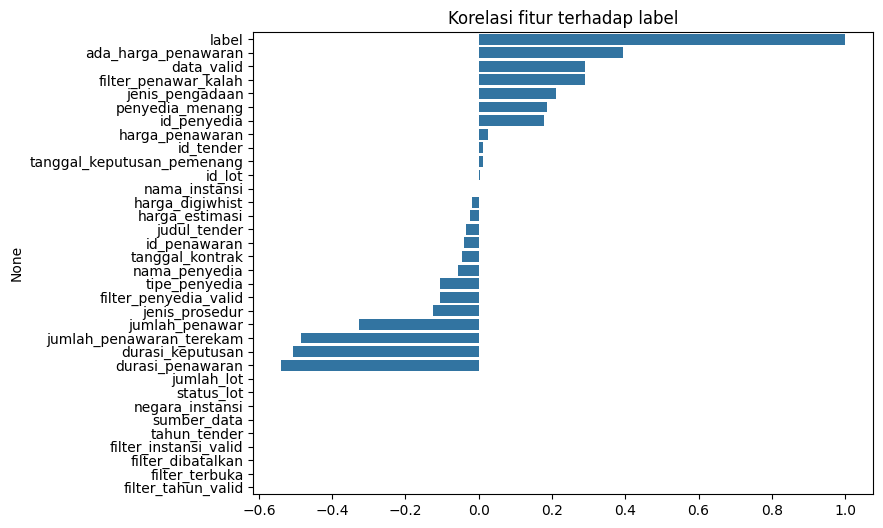

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = pd.concat([X, pd.Series(y, name="label")], axis=1)
corrs = df_corr.corr()["label"].sort_values(ascending=False)
print(corrs)

# Visualisasi
plt.figure(figsize=(8,6))
sns.barplot(y=corrs.index, x=corrs.values)
plt.title("Korelasi fitur terhadap label")
plt.show()


In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print("Akurasi Dummy Model:", dummy.score(X_test, y_test))


Akurasi Dummy Model: 0.49816057130491237


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Gunakan model sklearn untuk pembanding
clf = RandomForestClassifier(n_estimators=10, max_depth=10, random_state=42)
scores = cross_val_score(clf, X, y, cv=5)

print("Akurasi CV (mean):", scores.mean())


Akurasi CV (mean): 0.9803043886791993


In [89]:
from sklearn.preprocessing import LabelEncoder

# Cari kolom object / string
obj_cols = X.select_dtypes(include='object').columns

# Encode semua kolom kategorikal menjadi angka
for col in obj_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((79958, 10), (19990, 10), (79958,), (19990,))

Akurasi: 0.8360680340170085
Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91     17680
           1       0.32      0.37      0.34      2310

    accuracy                           0.84     19990
   macro avg       0.62      0.63      0.63     19990
weighted avg       0.85      0.84      0.84     19990



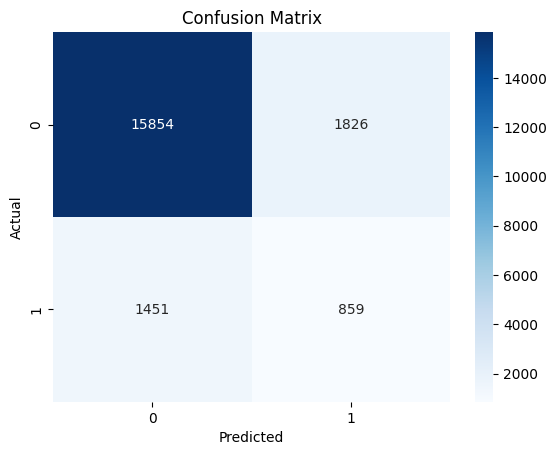

In [90]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random

class SVM:
    def __init__(self, max_iterations=1000, C=1, epsilon=0.001):
        self.max_iterations = max_iterations
        self.C = C
        self.epsilon = epsilon

    def fit(self, X, y):
        X = np.array(X).astype('float')
        y = np.array(y).astype('int')

        n, d = X.shape
        alpha = np.zeros(n)
        self.w = np.zeros(d)
        self.b = 0

        for iteration in range(self.max_iterations):
            alpha_prev = np.copy(alpha)
            for i in range(n):
                j = random.randint(0, n - 2)
                if j >= i:
                    j += 1

                x_i, y_i = X[i, :], y[i]
                x_j, y_j = X[j, :], y[j]

                nu = np.dot(x_i, x_i) + np.dot(x_j, x_j) - 2 * np.dot(x_i, x_j)
                if nu == 0:
                    continue

                E_i = self._E(x_i, y_i)
                E_j = self._E(x_j, y_j)

                L, H = self._bounds(alpha[i], alpha[j], y_i, y_j)

                if L == H:
                    continue

                new_alpha_j = alpha[j] + y_j * (E_i - E_j) / nu
                new_alpha_j = max(min(new_alpha_j, H), L)
                new_alpha_i = alpha[i] + y_i * y_j * (alpha[j] - new_alpha_j)

                delta_i = new_alpha_i - alpha[i]
                delta_j = new_alpha_j - alpha[j]

                self.w += delta_i * y_i * x_i + delta_j * y_j * x_j

                b1 = self.b - E_i - y_i * delta_i * np.dot(x_i, x_i) - y_j * delta_j * np.dot(x_i, x_j)
                b2 = self.b - E_j - y_i * delta_i * np.dot(x_i, x_j) - y_j * delta_j * np.dot(x_j, x_j)

                if 0 < new_alpha_i < self.C:
                    self.b = b1
                elif 0 < new_alpha_j < self.C:
                    self.b = b2
                else:
                    self.b = (b1 + b2) / 2

                alpha[i], alpha[j] = new_alpha_i, new_alpha_j

            if np.linalg.norm(alpha - alpha_prev) < self.epsilon:
                break

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b).astype(int)

    def _E(self, x, y):
        return self._f(x) - y

    def _f(self, x):
        return np.dot(x, self.w) + self.b

    def _bounds(self, alpha_i, alpha_j, y_i, y_j):
        if y_i != y_j:
            return max(0, alpha_j - alpha_i), min(self.C, self.C + alpha_j - alpha_i)
        else:
            return max(0, alpha_i + alpha_j - self.C), min(self.C, alpha_i + alpha_j)

# Inisialisasi dan latih model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_svm = np.where(y_train == 0, -1, 1)
y_test_svm = np.where(y_test == 0, -1, 1)

svm = SVM(max_iterations=500, C=5)
svm.fit(X_train, y_train_svm)

# Prediksi dan evaluasi
y_pred = svm.predict(X_test)
y_pred = np.where(y_pred == -1, 0, 1)
y_true = np.where(y_test == -1, 0, 1)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
